# Census Income Classification — Decision Tree vs Random Forest

**Dataset:** UCI Census Income (Adult) dataset  
**Task:** Predict whether an individual earns **more than $50K/year** from demographic and employment-related features.

## Portfolio objective

This project compares a Decision Tree with a Random Forest while paying attention to class imbalance, preprocessing leakage, model evaluation, interpretability, cross-validation, and hyperparameter tuning.

### Key questions

1. What does the dataset look like and how balanced is the target?
2. Which features are associated with the income classes?
3. How do a Decision Tree and Random Forest perform against a majority-class baseline?
4. How does the Random Forest perform on the minority `>50K` class?
5. Does hyperparameter tuning improve minority-class F1?
6. Which features contribute most to the Random Forest's predictions?
7. Does the `fnlwgt` survey-weight feature materially affect model performance?

### Workflow

**Data audit → EDA → train/test split → preprocessing pipeline → baseline models → evaluation → ROC-AUC → feature importance → cross-validation → hyperparameter tuning → `fnlwgt` sensitivity check → final comparison**

> **Portfolio note:** Preprocessing is fitted inside scikit-learn pipelines after the train/test split. This prevents information from the test set being used to learn preprocessing parameters.


## 1. Setup & Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score,
    StratifiedKFold
)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

pd.set_option("display.max_columns", None)

RANDOM_STATE = 32
sns.set_theme(style="whitegrid")


## 2. Load & Inspect Data



In [2]:
DATA_PATH = "data/census_income.csv"

# Optional fallback for the original Google Colab setup.
if not os.path.exists(DATA_PATH):
    fallback_path = "/content/census_income -TA Devansh.csv"
    if os.path.exists(fallback_path):
        DATA_PATH = fallback_path

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found at '{DATA_PATH}'. "
        "Place the CSV inside the project's data/ folder or update DATA_PATH."
    )

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())


Shape: (32561, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,annual_income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  annual_income   32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [4]:
display(df.describe(include="all").T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,32561.0,NaN,NaN,NaN,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
workclass,32561,9,Private,22696,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fnlwgt,32561.0,NaN,NaN,NaN,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education,32561,16,HS-grad,10501,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education-num,32561.0,NaN,NaN,NaN,10.080679,2.57272,1.0,9.0,10.0,12.0,16.0
marital-status,32561,7,Married-civ-spouse,14976,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation,32561,15,Prof-specialty,4140,NaN,NaN,NaN,NaN,NaN,NaN,NaN
relationship,32561,6,Husband,13193,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race,32561,5,White,27816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,32561,2,Male,21790,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Data Cleaning & Audit

The original dataset represents some unknown categorical values as the string `?`. These are converted to `NaN` and removed for this first portfolio version.

Duplicate rows are also checked and removed.

The target is normalized so labels such as `>50K` / `>50K.` are handled consistently if present.


In [5]:
print("Duplicate rows:", df.duplicated().sum())

question_mark_counts = (df == "?").sum()
question_mark_counts = question_mark_counts[question_mark_counts > 0]

print("\nColumns containing '?':")
display(question_mark_counts)

affected_rows = (df == "?").any(axis=1).sum()
print(f"Rows containing at least one '?': {affected_rows} "
      f"({affected_rows / len(df) * 100:.1f}%)")


Duplicate rows: 24

Columns containing '?':


,0
workclass,1836
occupation,1843
native-country,583


Rows containing at least one '?': 2399 (7.4%)


In [6]:
df = df.replace("?", np.nan)

before = len(df)
df = df.drop_duplicates().copy()
after_duplicates = len(df)

df = df.dropna().copy()
after_cleaning = len(df)

print(f"Rows after removing duplicates: {after_duplicates:,}")
print(f"Rows after removing rows with missing values: {after_cleaning:,}")
print(f"Total rows removed: {before - after_cleaning:,}")

target_col = "annual_income"
df[target_col] = (
    df[target_col]
    .astype(str)
    .str.replace(".", "", regex=False)
    .str.strip()
)

print("\nRemaining missing values:", int(df.isna().sum().sum()))
print("Target values:", df[target_col].unique())


Rows after removing duplicates: 32,537
Rows after removing rows with missing values: 30,139
Total rows removed: 2,422

Remaining missing values: 0
Target values: ['<=50K' '>50K']


## 4. Exploratory Data Analysis

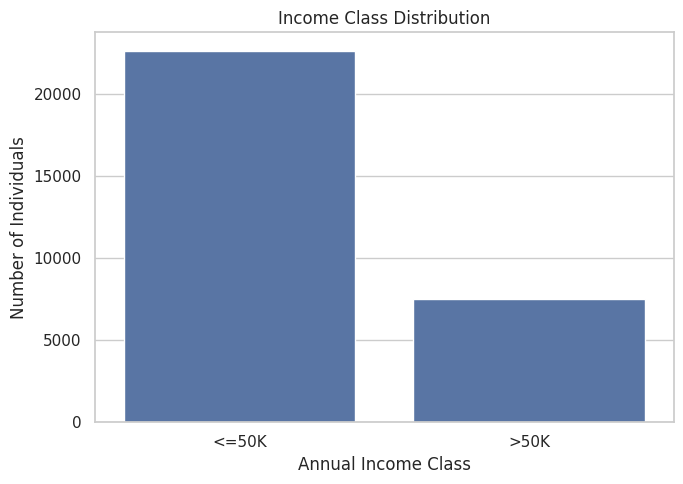

,Percentage
annual_income,
<=50K,75.1
>50K,24.9


In [7]:
# Target distribution
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x=target_col)
ax.set_title("Income Class Distribution")
ax.set_xlabel("Annual Income Class")
ax.set_ylabel("Number of Individuals")
plt.tight_layout()
plt.show()

class_balance = df[target_col].value_counts(normalize=True).mul(100).round(2)
display(class_balance.rename("Percentage"))


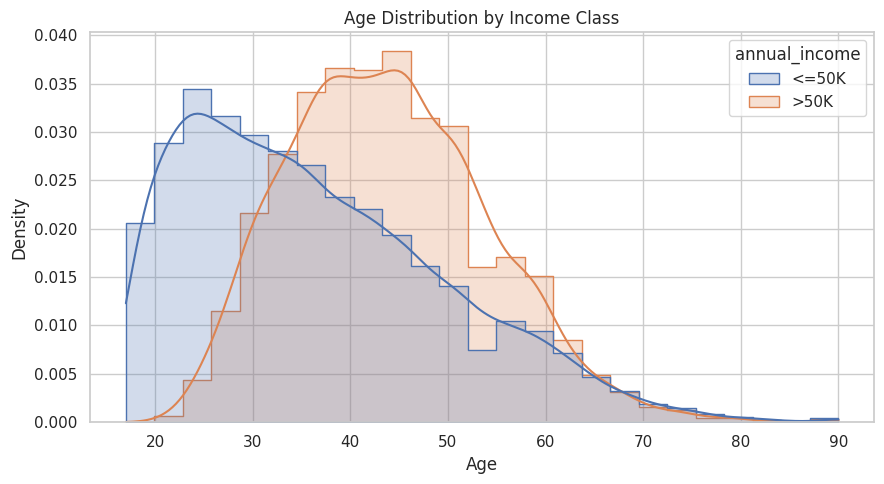

In [8]:
# Age distribution by income class
plt.figure(figsize=(9, 5))
sns.histplot(
    data=df,
    x="age",
    hue=target_col,
    bins=25,
    kde=True,
    element="step",
    stat="density",
    common_norm=False
)
plt.title("Age Distribution by Income Class")
plt.xlabel("Age")
plt.ylabel("Density")
plt.tight_layout()
plt.show()


<Figure size 1000x600 with 0 Axes>

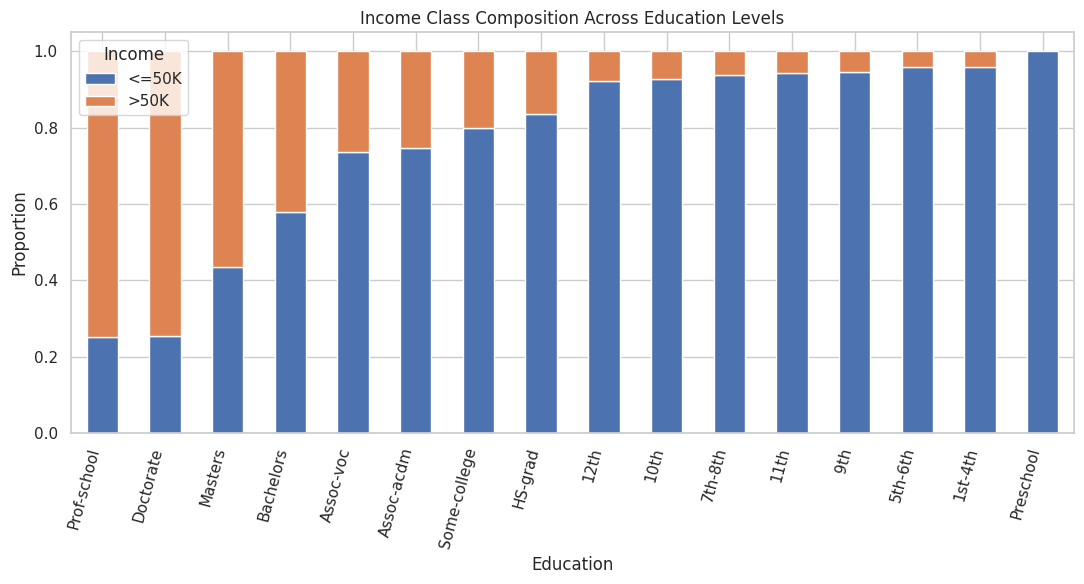

In [9]:
# Education level by income class
plt.figure(figsize=(10, 6))
education_income = pd.crosstab(
    df["education"],
    df[target_col],
    normalize="index"
).sort_values(">50K", ascending=False)

education_income.plot(kind="bar", stacked=True, figsize=(11, 6))
plt.title("Income Class Composition Across Education Levels")
plt.xlabel("Education")
plt.ylabel("Proportion")
plt.xticks(rotation=75, ha="right")
plt.legend(title="Income")
plt.tight_layout()
plt.show()


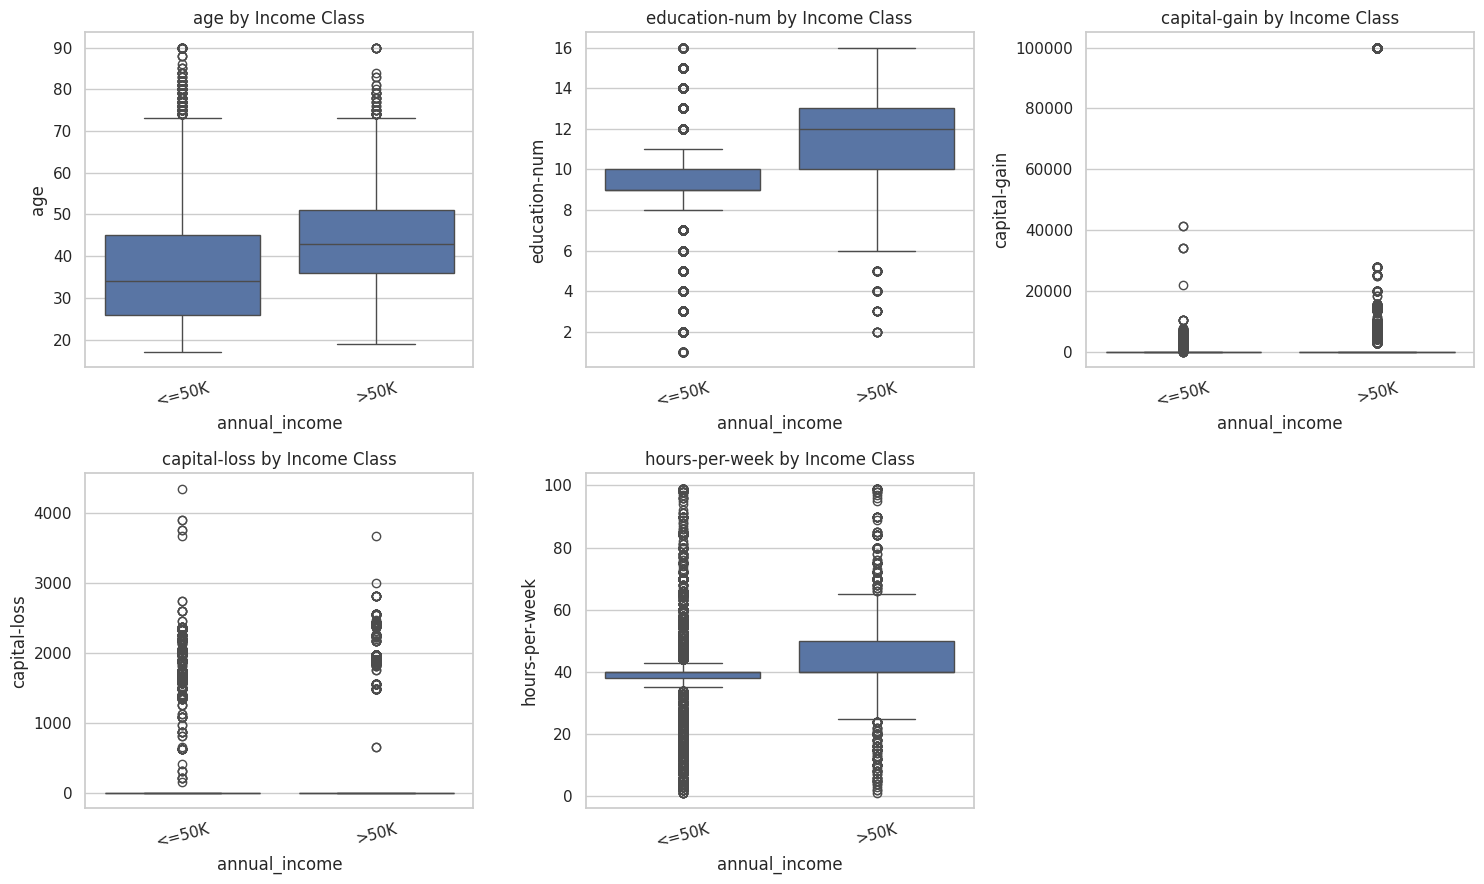

In [10]:
# Numeric feature distributions
numeric_eda = ["age", "education-num", "capital-gain", "capital-loss", "hours-per-week"]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, col in zip(axes, numeric_eda):
    sns.boxplot(data=df, x=target_col, y=col, ax=ax)
    ax.set_title(f"{col} by Income Class")
    ax.tick_params(axis="x", rotation=15)

axes[-1].axis("off")
plt.tight_layout()
plt.show()


### EDA observations

- The target is imbalanced, with the `<=50K` class forming the majority.
- Age, education, hours worked, and capital-gain show visible differences between income groups.
- These patterns motivate using class-specific metrics rather than accuracy alone.
- The EDA describes associations in the dataset; it does **not** establish that any feature causes higher income.


## 5. Define Target and Train/Test Split

The target is encoded as:

- `0` → `<=50K`
- `1` → `>50K`

The split happens **before** one-hot encoding. This is important because preprocessing should be learned from the training data only.


In [11]:
y = (df[target_col] == ">50K").astype(int)
X = df.drop(columns=[target_col])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTraining class distribution:")
display(y_train.value_counts(normalize=True).rename("proportion"))

baseline_accuracy = y_test.value_counts(normalize=True).max()
print(f"Majority-class baseline accuracy: {baseline_accuracy:.4f}")


Train shape: (24111, 14)
Test shape: (6028, 14)

Training class distribution:


,proportion
annual_income,
0,0.750944
1,0.249056


Majority-class baseline accuracy: 0.7510


## 6. Preprocessing Pipeline

Categorical variables are one-hot encoded with `handle_unknown="ignore"`.

Instead of encoding the complete dataset before splitting, preprocessing is placed inside a `ColumnTransformer` and model `Pipeline`. During cross-validation or fitting, the encoder is fitted only on the relevant training portion.

This makes the workflow more reproducible and avoids preprocessing leakage.


In [12]:
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()
numeric_cols = X_train.select_dtypes(exclude="object").columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("numeric", "passthrough", numeric_cols)
    ]
)

print("Categorical features:", categorical_cols)
print("Numeric features:", numeric_cols)


Categorical features: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
Numeric features: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']


## 7. Baseline Models — Decision Tree vs Random Forest

In [13]:
dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=5,
        random_state=RANDOM_STATE
    ))
])

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=50,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

dt_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

y_pred_dt = dt_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Decision Tree accuracy: {dt_accuracy:.4f}")
print(f"Random Forest accuracy: {rf_accuracy:.4f}")
print(f"Majority-class baseline: {baseline_accuracy:.4f}")


Decision Tree accuracy: 0.8414
Random Forest accuracy: 0.8520
Majority-class baseline: 0.7510


## 8. Model Evaluation

Because the target is imbalanced, accuracy is only one part of the evaluation.

For the minority `>50K` class, we focus on:

- **Precision:** Of those predicted as `>50K`, how many were actually `>50K`?
- **Recall:** Of all actual `>50K` cases, how many did the model identify?
- **F1:** Harmonic mean of precision and recall.
- **ROC-AUC:** How well the model ranks positive cases across thresholds.


In [14]:
def evaluate_classifier(model, X_eval, y_eval, name):
    predictions = model.predict(X_eval)
    probabilities = model.predict_proba(X_eval)[:, 1]

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_eval, predictions),
        "Precision (>50K)": precision_score(y_eval, predictions, zero_division=0),
        "Recall (>50K)": recall_score(y_eval, predictions, zero_division=0),
        "F1 (>50K)": f1_score(y_eval, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y_eval, probabilities)
    }

baseline_results = pd.DataFrame([
    evaluate_classifier(dt_pipeline, X_test, y_test, "Decision Tree"),
    evaluate_classifier(rf_pipeline, X_test, y_test, "Random Forest")
])

baseline_results.round(4)


,Model,Accuracy,Precision (>50K),Recall (>50K),F1 (>50K),ROC-AUC
0,Decision Tree,0.8414,0.7871,0.4977,0.6098,0.8856
1,Random Forest,0.8520,0.7377,0.6296,0.6794,0.8975


Random Forest classification report:

              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      4527
        >50K       0.74      0.63      0.68      1501

    accuracy                           0.85      6028
   macro avg       0.81      0.78      0.79      6028
weighted avg       0.85      0.85      0.85      6028



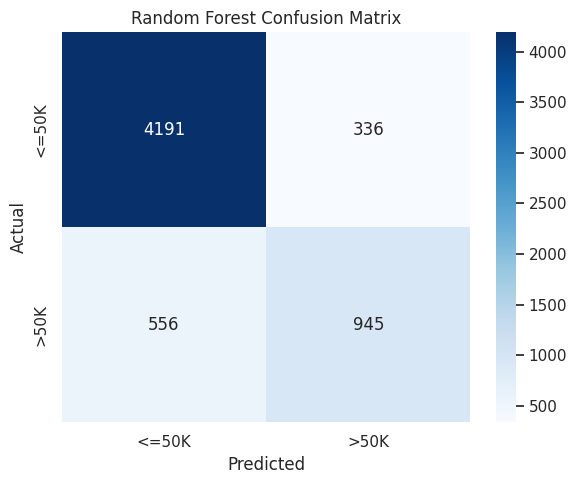

In [15]:
print("Random Forest classification report:\n")
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["<=50K", ">50K"]
    )
)

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["<=50K", ">50K"],
    yticklabels=["<=50K", ">50K"]
)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


## 9. ROC Curve & AUC

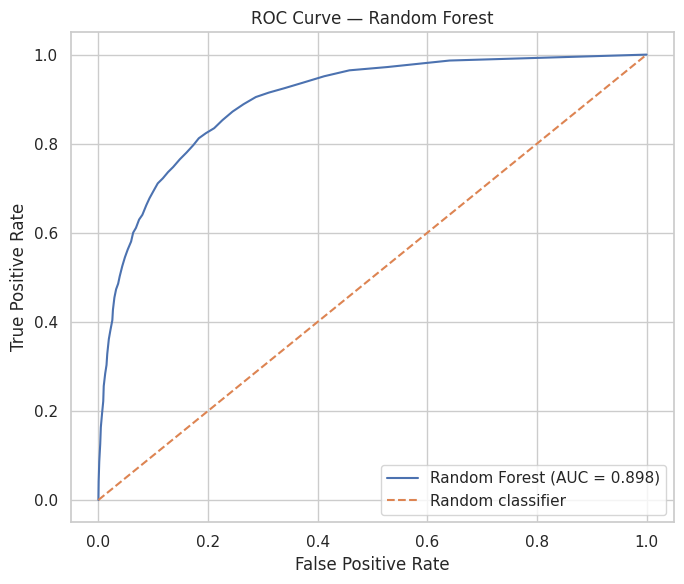

Random Forest ROC-AUC: 0.8975


In [16]:
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, y_proba_rf)

fpr, tpr, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {rf_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Random Forest ROC-AUC: {rf_auc:.4f}")


**Interpretation:** ROC-AUC evaluates ranking performance across classification thresholds. It is a useful complement to accuracy when class proportions are uneven, but it should be interpreted alongside precision, recall and F1 for the minority class.


## 10. Model Interpretability — Feature Importance

For the Random Forest, impurity-based feature importance is extracted after preprocessing.

One-hot encoded categories produce multiple transformed features, so the importance values are mapped back to the transformed feature names.


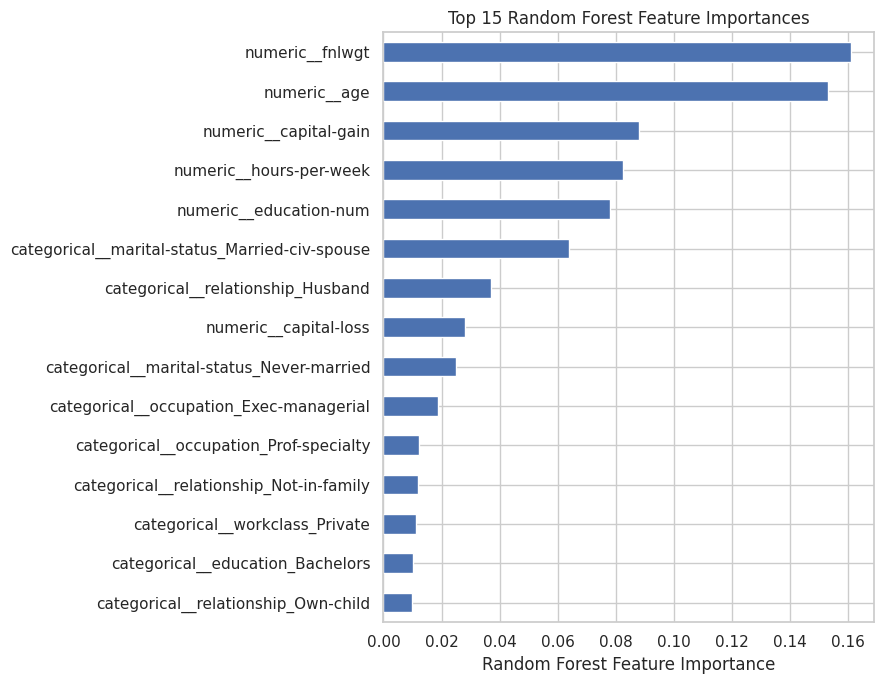

,Importance
numeric__fnlwgt,0.160797
numeric__age,0.152958
numeric__capital-gain,0.087951
numeric__hours-per-week,0.082281
numeric__education-num,0.077923
categorical__marital-status_Married-civ-spouse,0.063949
categorical__relationship_Husband,0.037088
numeric__capital-loss,0.028154
categorical__marital-status_Never-married,0.024902
categorical__occupation_Exec-managerial,0.018627


In [17]:
rf_model = rf_pipeline.named_steps["model"]
fitted_preprocessor = rf_pipeline.named_steps["preprocessor"]

feature_names = fitted_preprocessor.get_feature_names_out()
importances = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

top_importances = importances.head(15).sort_values()

plt.figure(figsize=(9, 7))
top_importances.plot(kind="barh")
plt.xlabel("Random Forest Feature Importance")
plt.title("Top 15 Random Forest Feature Importances")
plt.tight_layout()
plt.show()

display(importances.head(15).to_frame("Importance"))


### Interpreting feature importance carefully

Feature importance tells us which variables contributed strongly to the Random Forest's predictive decisions. It does **not** prove that a feature causes higher income.

In this dataset, variables such as `fnlwgt`, `age`, `capital-gain`, `hours-per-week`, and `education-num` can emerge as important. The exact ordering should be taken from the model output above rather than assumed in advance.


## 11. Decision Tree Visualization

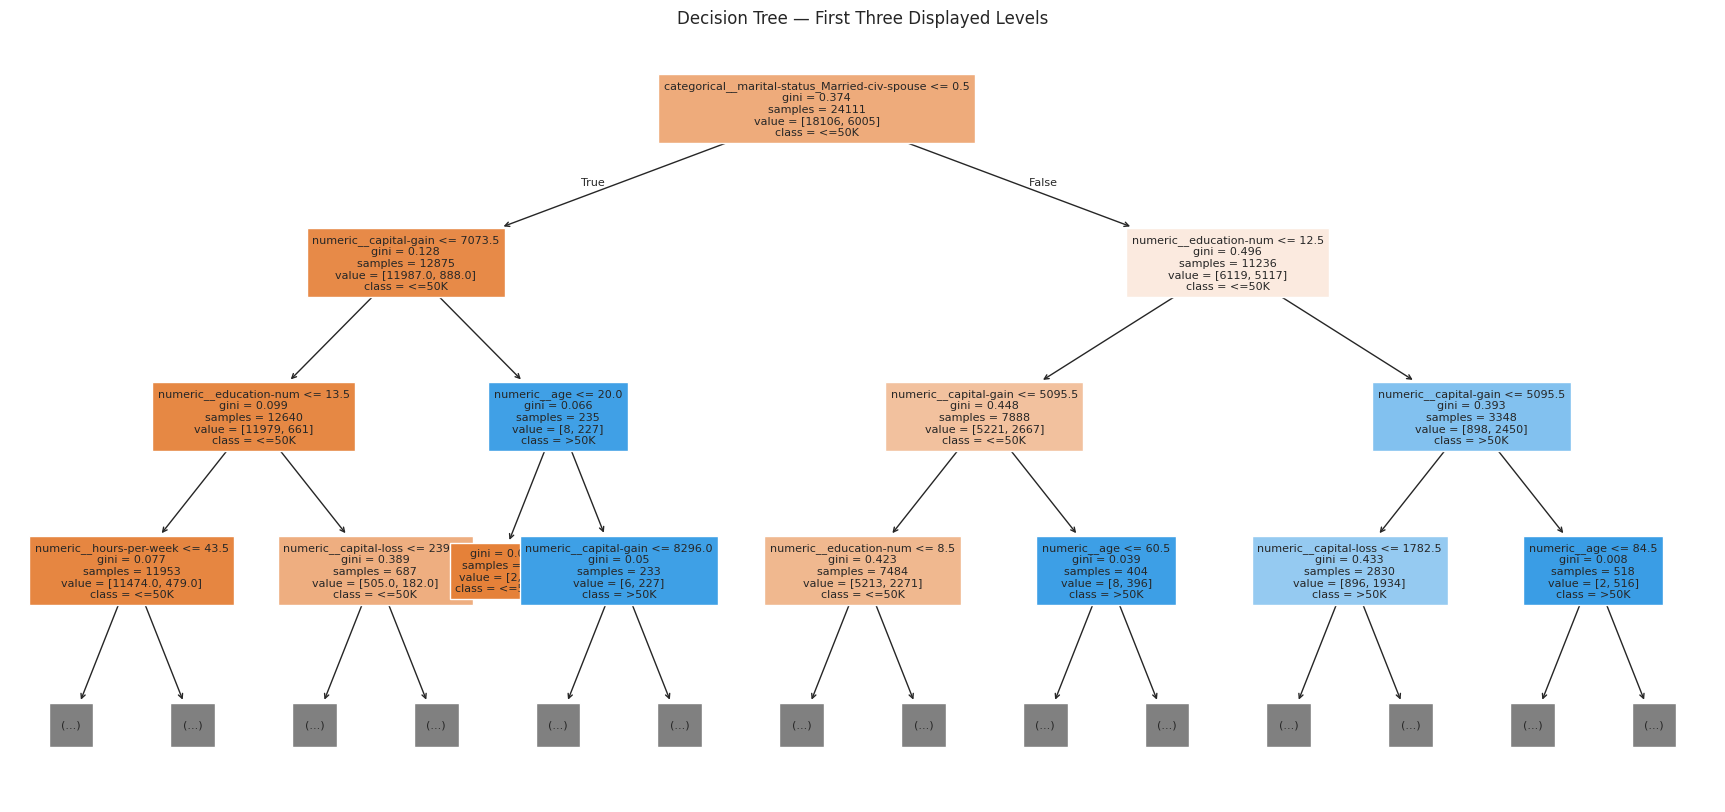

In [18]:
dt_model = dt_pipeline.named_steps["model"]
dt_preprocessor = dt_pipeline.named_steps["preprocessor"]

dt_feature_names = dt_preprocessor.get_feature_names_out()

plt.figure(figsize=(22, 10))
plot_tree(
    dt_model,
    feature_names=dt_feature_names,
    class_names=["<=50K", ">50K"],
    filled=True,
    max_depth=3,
    fontsize=8
)
plt.title("Decision Tree — First Three Displayed Levels")
plt.show()


## 12. Cross-Validation

Cross-validation provides a more stable estimate than relying on one train/test split.

The same preprocessing pipeline is evaluated inside each fold, so the encoder is refitted only on each fold's training portion.


In [19]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_accuracy = cross_val_score(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

cv_f1 = cross_val_score(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

print("Accuracy CV scores:", np.round(cv_accuracy, 4))
print(f"Mean accuracy: {cv_accuracy.mean():.4f}")
print(f"Std accuracy:  {cv_accuracy.std():.4f}")

print("\nMinority-class F1 CV scores:", np.round(cv_f1, 4))
print(f"Mean F1: {cv_f1.mean():.4f}")
print(f"Std F1:  {cv_f1.std():.4f}")


Accuracy CV scores: [0.8526 0.8455 0.8476 0.8426 0.847 ]
Mean accuracy: 0.8470
Std accuracy:  0.0033

Minority-class F1 CV scores: [0.6749 0.6664 0.6735 0.6583 0.6685]
Mean F1: 0.6683
Std F1:  0.0059


## 13. Hyperparameter Tuning

The baseline Random Forest uses fixed settings. Here, GridSearchCV searches a small parameter grid.

The optimization metric is **F1 for the `>50K` class**, because accuracy can hide weak minority-class performance.


In [22]:
tuned_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 15]
}

grid_search = GridSearchCV(
    tuned_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

print("Best parameters:")
print(grid_search.best_params_)
print(f"Best CV F1 (>50K): {grid_search.best_score_:.4f}")


Best parameters:
{'model__max_depth': 15, 'model__n_estimators': 100}
Best CV F1 (>50K): 0.6697


In [24]:
tuned_results = pd.DataFrame([
    evaluate_classifier(
        best_rf,
        X_test,
        y_test,
        "Tuned Random Forest"
    )
])

display(tuned_results.round(4))

print("Tuned Random Forest classification report:\n")
print(
    classification_report(
        y_test,
        best_rf.predict(X_test),
        target_names=["<=50K", ">50K"]
    )
)


,Model,Accuracy,Precision (>50K),Recall (>50K),F1 (>50K),ROC-AUC
0,Tuned Random Forest,0.8583,0.7881,0.5896,0.6745,0.9141


Tuned Random Forest classification report:

              precision    recall  f1-score   support

       <=50K       0.87      0.95      0.91      4527
        >50K       0.79      0.59      0.67      1501

    accuracy                           0.86      6028
   macro avg       0.83      0.77      0.79      6028
weighted avg       0.85      0.86      0.85      6028



## 14. `fnlwgt` Sensitivity Check

The baseline Random Forest may assign substantial importance to `fnlwgt`, a survey-weight variable in the Adult dataset.

Rather than assuming that importance is meaningful, we test the model with and without `fnlwgt`.

This is a **sensitivity analysis**, not proof that the feature should or should not be used.


In [25]:
X_without_fnlwgt = X.drop(columns=["fnlwgt"])
X_train_no_weight, X_test_no_weight, y_train_no_weight, y_test_no_weight = train_test_split(
    X_without_fnlwgt,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

categorical_no_weight = X_train_no_weight.select_dtypes(include="object").columns.tolist()
numeric_no_weight = X_train_no_weight.select_dtypes(exclude="object").columns.tolist()

preprocessor_no_weight = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_no_weight),
        ("numeric", "passthrough", numeric_no_weight)
    ]
)

rf_without_fnlwgt = Pipeline([
    ("preprocessor", preprocessor_no_weight),
    ("model", RandomForestClassifier(
        n_estimators=50,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_without_fnlwgt.fit(X_train_no_weight, y_train_no_weight)

with_weight = evaluate_classifier(
    rf_pipeline, X_test, y_test, "Random Forest — with fnlwgt"
)

without_weight = evaluate_classifier(
    rf_without_fnlwgt,
    X_test_no_weight,
    y_test_no_weight,
    "Random Forest — without fnlwgt"
)

fnlwgt_comparison = pd.DataFrame([with_weight, without_weight])
display(fnlwgt_comparison.round(4))


,Model,Accuracy,Precision (>50K),Recall (>50K),F1 (>50K),ROC-AUC
0,Random Forest — with fnlwgt,0.8520,0.7377,0.6296,0.6794,0.8975
1,Random Forest — without fnlwgt,0.8447,0.7122,0.6316,0.6695,0.8859


### How to read the sensitivity check

If performance changes meaningfully after removing `fnlwgt`, that tells us the model is using information associated with this feature. It does not by itself establish whether the feature is substantively useful or causal.

For a portfolio project, the important point is that the feature was **questioned and tested rather than blindly accepted**.


## 15. Final Model Comparison

In [26]:
final_comparison = pd.concat(
    [
        baseline_results,
        tuned_results
    ],
    ignore_index=True
)


baseline_row = pd.DataFrame([{
    "Model": "Majority-Class Baseline",
    "Accuracy": baseline_accuracy,
    "Precision (>50K)": np.nan,
    "Recall (>50K)": np.nan,
    "F1 (>50K)": np.nan,
    "ROC-AUC": np.nan
}])

final_comparison = pd.concat(
    [baseline_row, final_comparison],
    ignore_index=True
)

display(final_comparison.round(4))


,Model,Accuracy,Precision (>50K),Recall (>50K),F1 (>50K),ROC-AUC
0,Majority-Class Baseline,0.7510,NaN,NaN,NaN,NaN
1,Decision Tree,0.8414,0.7871,0.4977,0.6098,0.8856
2,Random Forest,0.8520,0.7377,0.6296,0.6794,0.8975
3,Tuned Random Forest,0.8583,0.7881,0.5896,0.6745,0.9141


## 16. Key Findings

### What the analysis shows

- The target is imbalanced, so the majority-class baseline is an important reference point.
- A single Decision Tree and Random Forest both improve on the majority-class baseline.
- Random Forest provides a stronger ensemble-based model than the single Decision Tree in this experiment.
- Minority-class `>50K` performance is weaker than majority-class performance, making precision, recall and F1 important alongside accuracy.
- ROC-AUC provides an additional view of ranking performance across thresholds.
- Cross-validation checks whether the model's performance is reasonably stable across different training folds.
- Hyperparameter tuning is evaluated using minority-class F1 rather than accuracy.
- Feature importance is interpreted as predictive contribution, not causation.
- The `fnlwgt` sensitivity check tests whether model performance depends materially on that feature.

### Important limitation

This is a predictive modeling exercise. The model should not be interpreted as identifying the causes of income differences or as making individual socioeconomic judgments.


## 17. Limitations & Possible Extensions

### Limitations

- Unknown-value rows were removed rather than imputed.
- The dataset contains demographic and socioeconomic variables, so model performance should not automatically be interpreted as evidence of fairness.
- Impurity-based feature importance can be biased toward certain feature types and should not be treated as causal evidence.
- The project compares tree-based models rather than an exhaustive set of classification algorithms.
- The train/test evaluation is based on one held-out split, although cross-validation is also used on the training data.

### Possible extensions

- Compare with Logistic Regression as a more interpretable linear baseline.
- Investigate threshold tuning for the `>50K` class.
- Compare alternative class-imbalance strategies.
- Evaluate calibration of predicted probabilities.
- Compare with a gradient-boosting model.
- Perform a more detailed fairness analysis across demographic groups.


# Conclusion

This project demonstrates a complete supervised machine-learning workflow for census income classification:

**data audit → EDA → leakage-safe preprocessing → baseline models → class-aware evaluation → ROC-AUC → interpretability → cross-validation → hyperparameter tuning → sensitivity analysis**

The main lesson is that a good ML project is not simply about obtaining the highest accuracy. The analysis also needs to explain **what the model is learning, how reliable the evaluation is, how the minority class performs, and what limitations remain.**
